In [1]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.etl.ingest import load_nvdrs

# If you just want to see the whole data config dictionary
#from src.utils.config import load_config
# data_config = load_config("data.yaml")

In [2]:
#nvdrs_head_df = load_nvdrs(file_key="nvdrs", data_folder="raw", nrows=10000)
#nvdrs_head_df.columns.tolist()#list(nvdrs_head_df.columns)
#nvdrs_narrative_df = load_nvdrs(file_key="nvdrs_narratives", data_folder="raw")

usecols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberWeapons_c', 'NumberSuspects_c', 'NumberSubstances_c', 'NumberSubstancesCausedDeath_c', 'Sex', 'AgeYears_c', 'Country', 'ResidenceState', 'ResidenceFIPS', 'ResidenceCityState', 'ResidenceZip', 'Homeless', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType', 'RecentRelease', 'AlcoholUseSuspected', 'ExternalCause1ICD9', 'ExternalCause2ICD9', 'UnderlyingCauseCode', 'DeathCause1', 'DeathCause2', 'DeathCause3', 'OtherCondition', 'HowInjuryOccurred', 'DeathDate', 'DeathDate_myr', 'DeathDate_year', 'DeathState', 'DeathFIPS', 'MultipleConditionCode01ICD10', 'MultipleConditionCode02ICD10', 'MultipleConditionCode03ICD10', 'MultipleConditionCode04ICD10', 'MultipleConditionCode05ICD10', 'MultipleConditionCode06ICD10', 'MultipleConditionCode07ICD10', 'MultipleConditionCode08ICD10', 'MultipleConditionCode09ICD10', 'MultipleConditionCode10ICD10', 'CME_CircumstancesOtherText', 'CME_CrisisOtherDescription', 'LE_CircumstancesOtherText', 'LE_CrisisOtherDescription', 'SuicideAttemptHistory_c', 'SuicideThoughtHistory_c', 'HistorySelfHarm_c']
uselesscols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberSuspects_c', 'Sex', 'AgeYears_c', 'Country', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType']
nvdrs_df = load_nvdrs(file_key="nvdrs", data_folder="raw", usecols=uselesscols)

In [ ]:
#GET INCIDENT CATEGORY THAT CONTAINS 'suicide' 
#categories = nvdrs_df['IncidentCategory_c'].dropna()
#mask = categories.str.contains('suicide', case=False)
#categories[mask].unique().tolist()

In [6]:
# selecting suicides
nvdrs_s_df=nvdrs_df.loc[nvdrs_df['IncidentCategory_c'].str.contains('suicide', case=False, na=False),]

# Removing victimes of homsuicideicide/suicide incidents (keeping the suicide suspect only)
# keep the 'PersonType' == "Both victim and suspect"
mask = nvdrs_s_df['IncidentCategory_c'] == 'Single suicide'
single = nvdrs_s_df[mask]
others = nvdrs_s_df[~mask]
idx = (others['PersonType'] == 'Both victim and suspect').groupby(others['IncidentID']).idxmax()
nvdrs_s_df = pd.concat([single, others.loc[idx]], ignore_index=True)
#9,277 rows removed
del single, others, mask, idx

In [7]:
#clean up memory
del nvdrs_df

In [ ]:
from darts import TimeSeries


# Convert to datetime if it isn't already
nvdrs_s_df['InjuryDate'] = pd.to_datetime(nvdrs_s_df['InjuryDate'])

# Count incidents per day
daily_df = nvdrs_s_df.groupby('InjuryDate').size().reset_index(name='incident_count')

# Create TimeSeries
nvdrs_ts = TimeSeries.from_dataframe(
    daily_df, 
    time_col='InjuryDate', 
    value_cols='incident_count',
    fill_missing_dates=True, 
    freq='D',           # Explicitly set Daily frequency
    fillna_value=0      # Fill missing days with 0 incidents
)
nvdrs_ts.head


,incident_count
InjuryDate,
1916-01-13,1.0
1916-01-14,0.0
1916-01-15,0.0
1916-01-16,0.0
1916-01-17,0.0


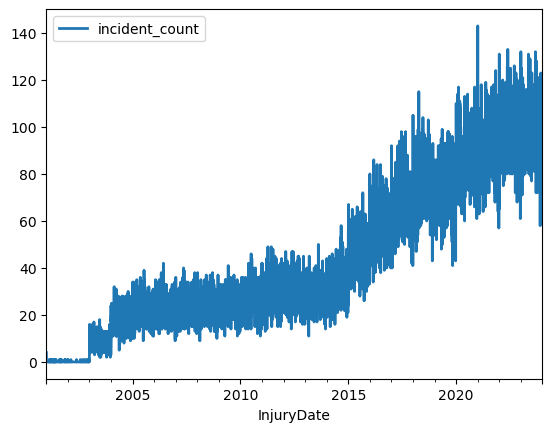

In [13]:
import matplotlib.pyplot as plt

nvdrs_ts = nvdrs_ts[pd.Timestamp('2001-01-01'):].plot()
plt.show()

Number of series components (55) is larger than the maximum number of components to plot (10). Plotting only the first `10` components. You can adjust the number of components to plot using `max_nr_components`.


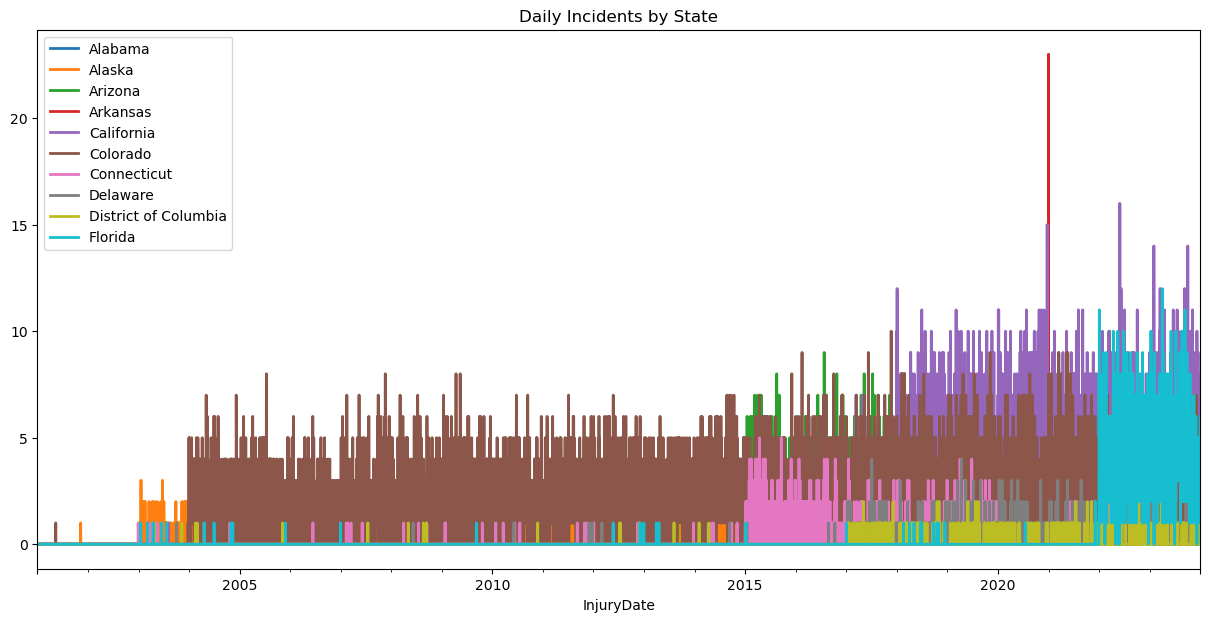

In [28]:
#MULTIVARIATE TIME SERIES
# 1. Group by BOTH Date and State, then count
daily_df = nvdrs_s_df.groupby(['InjuryDate', 'InjuryState']).size().reset_index(name='incident_count')

# 2. Pivot the table so rows are Dates, columns are States, and values are counts
pivoted_df = daily_df.pivot(
    index='InjuryDate', 
    columns='InjuryState', 
    values='incident_count'
).reset_index()

# 3. Fill any NaNs (days where a specific state had 0 incidents) with 0
pivoted_df = pivoted_df.fillna(0)


nvdrs_ts_states = TimeSeries.from_dataframe(
    pivoted_df,
    time_col='InjuryDate',
    fill_missing_dates=True, 
    freq='D',                
    fillna_value=0           
)




selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

plt.figure(figsize=(15, 7))
nvdrs_ts_states[pd.Timestamp('2001-01-01'):].plot()

plt.title("Daily Incidents by State")
plt.show()


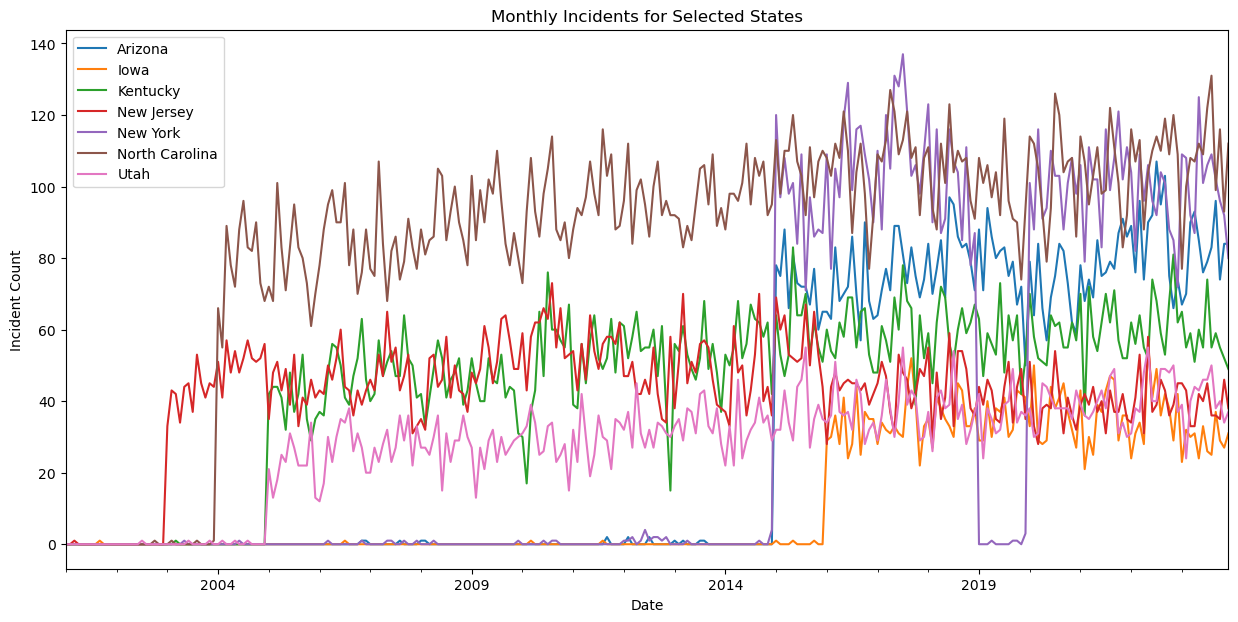

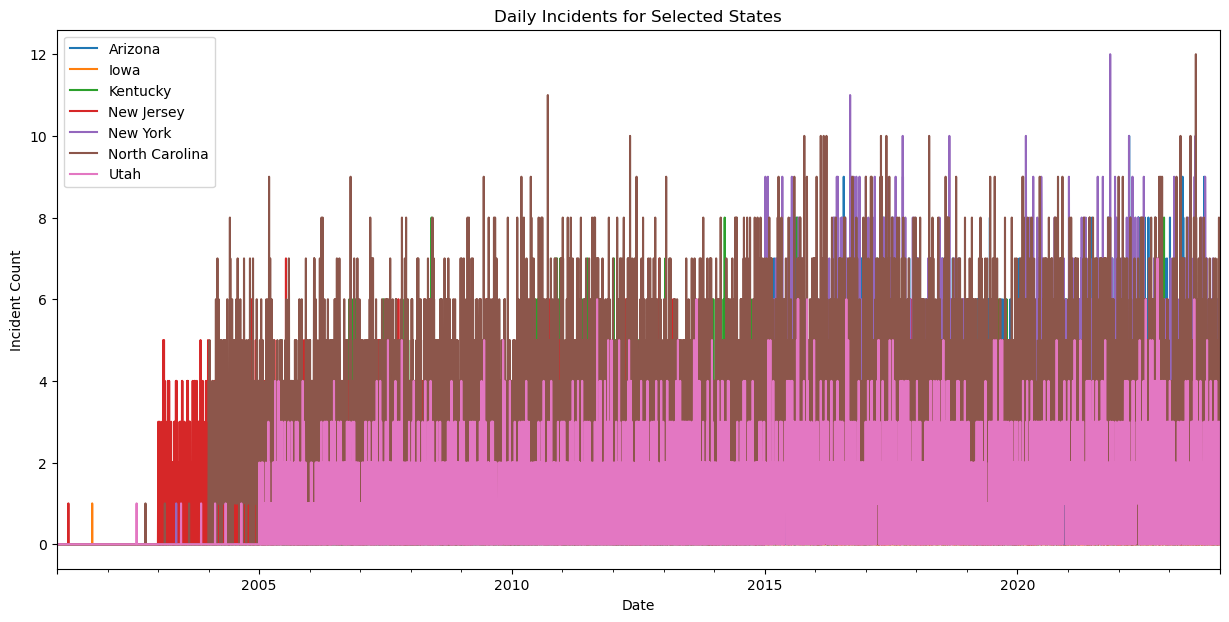

In [ ]:
# Extract, resample to Monthly ('ME'), sum the daily counts, and plot

monthly_df = nvdrs_ts_states[pd.Timestamp('2001-01-01'):].to_dataframe().resample('ME').sum() #calculates
daily_df = nvdrs_ts_states[pd.Timestamp('2001-01-01'):].to_dataframe()
#selected_states = ['New York', 'California', 'Texas', 'Wyoming', 'Alaska', 'Montana', 'New Mexico']
selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']
# Filter the monthly dataframe to just these columns and plot
monthly_df[selected_states].plot(figsize=(15, 7))

plt.title("Monthly Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()


daily_df[selected_states].plot(figsize=(15, 7))

plt.title("Daily Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()

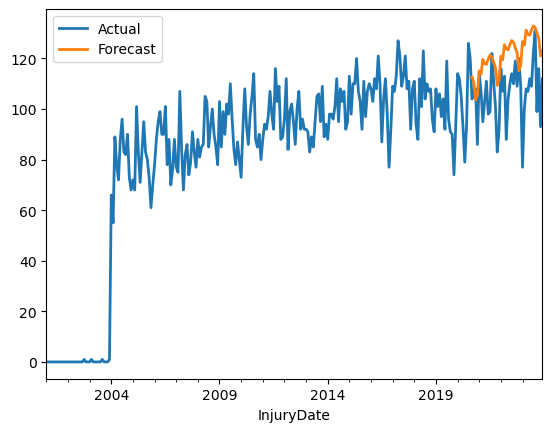

In [33]:
from darts import TimeSeries
from darts.models import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert pandas DataFrame back to a Darts TimeSeries
ts_monthly = TimeSeries.from_dataframe(monthly_df.reset_index(), time_col='InjuryDate')

# 2. Isolate one state (simple models require univariate series)
ts_ny = ts_monthly['North Carolina']

# 3. Split data (train on history, validate on the last 36 months)
train, val = ts_ny[:-40], ts_ny[-40:]

# 4. Initialize and fit
model = ExponentialSmoothing()
model.fit(train)

# 5. Predict and plot
prediction = model.predict(len(val))

ts_ny.plot(label='Actual')
prediction.plot(label='Forecast', lw=2)
plt.legend()
plt.show()

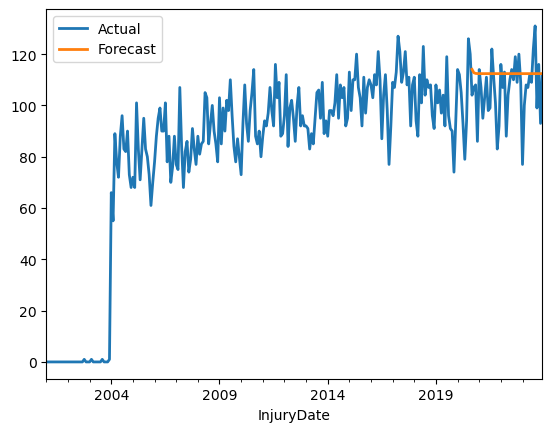

In [35]:
from darts.models import AutoARIMA

# Initialize and fit on New York
arima_model = AutoARIMA()
arima_model.fit(train)

# Predict and plot
arima_pred = arima_model.predict(len(val))

ts_ny.plot(label='Actual')
arima_pred.plot(label='Forecast', lw=2)
plt.legend()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11873
[LightGBM] [Info] Number of data points in the train set: 228, number of used features: 583
[LightGBM] [Info] Start training from score 8.596491
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

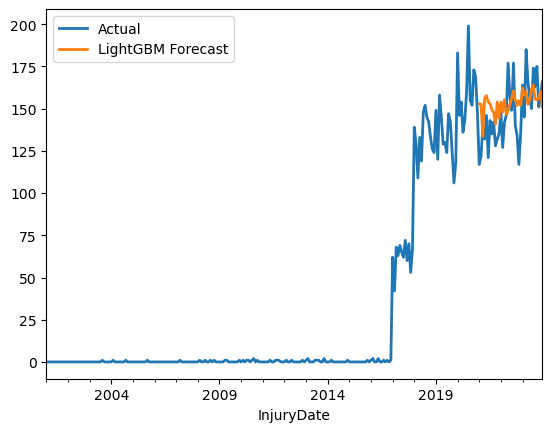

In [ ]:
from darts.models import LightGBMModel

# 1. Split the entire multivariate series (all states)
train_multi, val_multi = ts_monthly[:-36], ts_monthly[-36:]

# 2. Initialize LightGBM 
# lags=12 means it uses the past 12 months to predict the next month
lgbm_model = LightGBMModel(lags=12)

# 3. Fit on all states simultaneously
lgbm_model.fit(train_multi)

# 4. Predict the next 36 months for all states
lgbm_pred = lgbm_model.predict(len(val_multi))


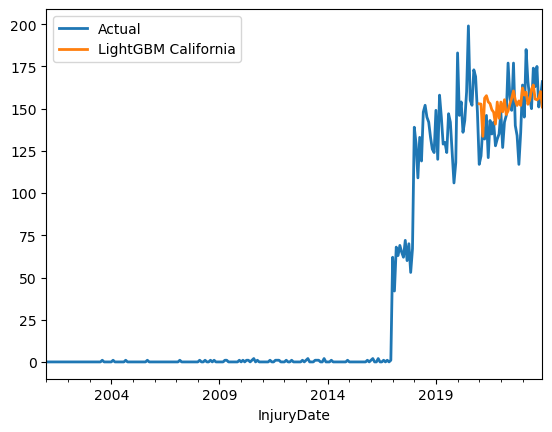

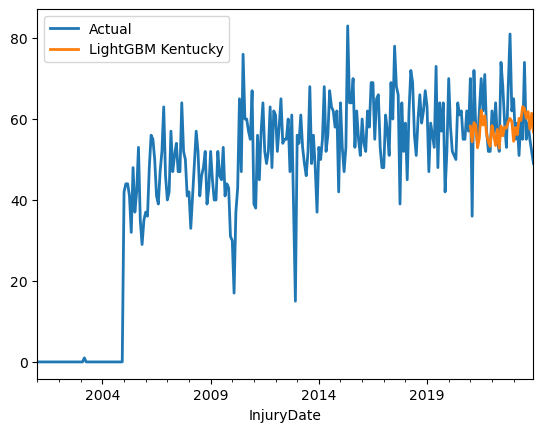

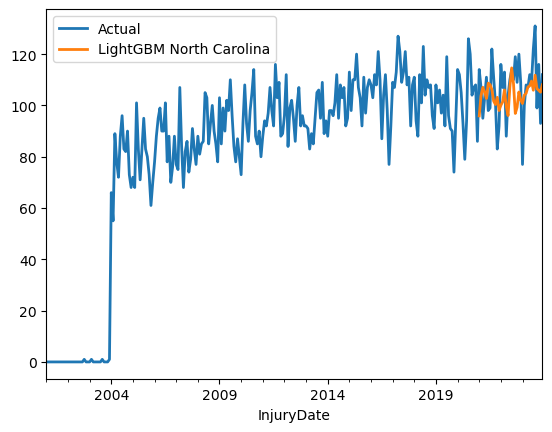

In [37]:

# 5. Plot a specific state's result (e.g., California)
ts_monthly['California'].plot(label='Actual')
lgbm_pred['California'].plot(label='LightGBM California', lw=2)
plt.legend()
plt.show()

ts_monthly['Kentucky'].plot(label='Actual')
lgbm_pred['Kentucky'].plot(label='LightGBM Kentucky', lw=2)
plt.legend()
plt.show()


ts_monthly['North Carolina'].plot(label='Actual')
lgbm_pred['North Carolina'].plot(label='LightGBM North Carolina', lw=2)
plt.legend()
plt.show()